## **Restoration and Segmentation of Diseased Regions in Plant Leaf Images Using Digital Image**

This initiates the file upload process, allowing you to select and upload a `.zip` file containing the dataset from your local machine to the Colab environment. The uploaded file is saved as `leaf.zip`.

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving leaf.zip to leaf.zip


This cell extracts the contents of the uploaded `leaf.zip` file into a new directory named `/content/Leaf_DIP_Project`. This makes the image and mask files accessible for further processing.

In [ ]:
import zipfile
import os

zip_file = list(uploaded.keys())[0]

extract_path = "/content/Leaf_DIP_Project"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


This cell inspects the extracted dataset structure. It walks through the `/content/Leaf_DIP_Project` directory, identifies subfolders containing image files, and prints the number of files and a sample of file names within each folder. This helps verify the extraction and understand the data organization.

In [ ]:
for root, dirs, files_list in os.walk(extract_path):
    if files_list:
        print("\nFolder:", root)
        print("Number of files:", len(files_list))
        print("Sample files:", files_list[:5])


Folder: /content/Leaf_DIP_Project/leaf/image
Number of files: 10
Sample files: ['00000_3.jpg', '00000_0.jpg', '00000_2.jpg', '00001_2.jpg', '00001_1.jpg']

Folder: /content/Leaf_DIP_Project/leaf/masks
Number of files: 10
Sample files: ['00000_2.png', '00001_3.png', '00000_3.png', '00001_2.png', '00000_4.png']


This cell defines and prints the specific paths to the directories containing the original plant leaf images (`image_folder`) and their corresponding masks (`mask_folder`). These paths will be used to load the data in subsequent steps.

In [ ]:
image_folder = "/content/Leaf_DIP_Project/leaf/image"
mask_folder = "/content/Leaf_DIP_Project/leaf/masks"

print("Image folder:", image_folder)
print("Mask folder:", mask_folder)

Image folder: /content/Leaf_DIP_Project/leaf/image
Mask folder: /content/Leaf_DIP_Project/leaf/masks


This cell imports all the necessary libraries for image processing, numerical operations, and plotting. It includes `cv2` (OpenCV) for image manipulation, `numpy` for numerical operations, `matplotlib.pyplot` for visualization, and `skimage.metrics` for calculating image quality metrics like MSE, PSNR, and SSIM.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.metrics import mean_squared_error
from skimage.metrics import peak_signal_noise_ratio
from skimage.metrics import structural_similarity

This cell identifies and selects a subset of image files from the `image_folder` for processing. It filters for common image extensions (jpg, jpeg, png, bmp), sorts the filenames, and then selects the first 10 images. The selected filenames are then printed to confirm the list of images that will be analyzed.

In [ ]:
image_files = []

for file in os.listdir(image_folder):
    if file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
        image_files.append(file)

image_files = sorted(image_files)[:10]

print("Number of selected images:", len(image_files))

for file in image_files:
    print(file)

Number of selected images: 10
00000_0.jpg
00000_1.jpg
00000_2.jpg
00000_3.jpg
00000_4.jpg
00001_0.jpg
00001_1.jpg
00001_2.jpg
00001_3.jpg
00001_4.jpg


This cell loads the first image from the `image_files` list, converts it from BGR to RGB color format (as OpenCV reads BGR by default), and displays it using `matplotlib`. It also prints the image name and its dimensions (height, width, channels) to provide basic information about the selected image.

Image: 00000_0.jpg
Image size: (235, 326, 3)


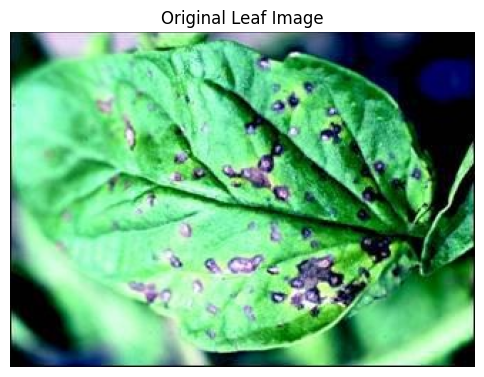

In [ ]:
image_name = image_files[0]

image_path = os.path.join(image_folder, image_name)

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print("Image:", image_name)
print("Image size:", image.shape)

plt.figure(figsize=(6,6))
plt.imshow(image)
plt.title("Original Leaf Image")
plt.axis("off")
plt.show()

This cell lists all available mask files in the `mask_folder` and confirms the name of the image currently being processed. This step ensures that the corresponding mask for the selected image can be identified and loaded.

In [ ]:
print("Selected image:")
print(image_name)

print("\nAvailable masks:")
print(sorted(os.listdir(mask_folder)))

Selected image:
00000_0.jpg

Available masks:
['00000_0.png', '00000_1.png', '00000_2.png', '00000_3.png', '00000_4.png', '00001_0.png', '00001_1.png', '00001_2.png', '00001_3.png', '00001_4.png']


This cell constructs the file path for the mask corresponding to the selected image, loads it as a grayscale image, and prints its name and dimensions. The mask will serve as the ground truth for evaluating segmentation performance.

In [ ]:
mask_name = os.path.splitext(image_name)[0] + ".png"

mask_path = os.path.join(mask_folder, mask_name)

mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

print("Mask:", mask_name)
print("Mask size:", mask.shape)

Mask: 00000_0.png
Mask size: (235, 326)


This cell displays both the original plant leaf image and its corresponding ground truth mask side-by-side. This visual comparison helps to understand the target segmentation and provides a reference for the image processing results.

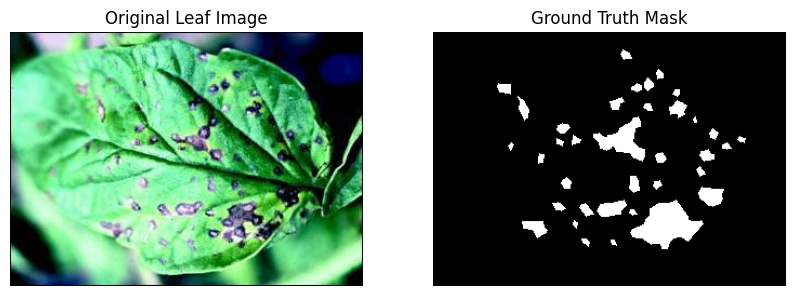

In [ ]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original Leaf Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.show()

This cell converts the original color image into a grayscale image. Grayscale conversion is often a prerequisite for many image processing operations, such as noise reduction and thresholding.

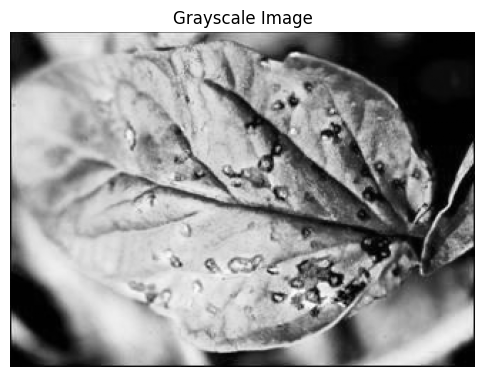

In [ ]:
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(6,6))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

This cell simulates real-world image degradation by adding Gaussian noise to the grayscale image. Gaussian noise is a common type of noise that can occur during image acquisition, and this step prepares the image for noise reduction techniques.

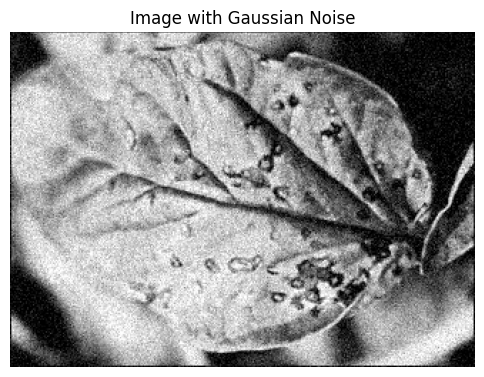

In [ ]:
noise = np.random.normal(0, 20, gray.shape)

noisy = gray.astype(np.float32) + noise

noisy = np.clip(noisy, 0, 255).astype(np.uint8)

plt.figure(figsize=(6,6))
plt.imshow(noisy, cmap="gray")
plt.title("Image with Gaussian Noise")
plt.axis("off")
plt.show()

This cell applies a mean filter (averaging filter) to the noisy grayscale image. The mean filter is a simple linear filter used for smoothing images and reducing noise by replacing each pixel value with the average of its neighbors within a defined kernel size (here, 5x5).

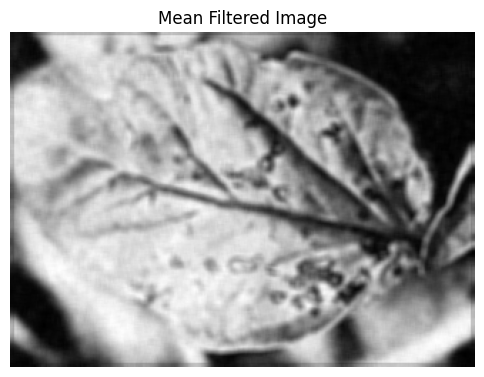

In [ ]:
mean_filtered = cv2.blur(noisy, (5,5))

plt.figure(figsize=(6,6))
plt.imshow(mean_filtered, cmap="gray")
plt.title("Mean Filtered Image")
plt.axis("off")
plt.show()

This cell applies a median filter to the noisy grayscale image. The median filter is a non-linear filter that is particularly effective at removing salt-and-pepper noise while preserving edges better than a mean filter. It replaces each pixel's value with the median value of its neighbors.

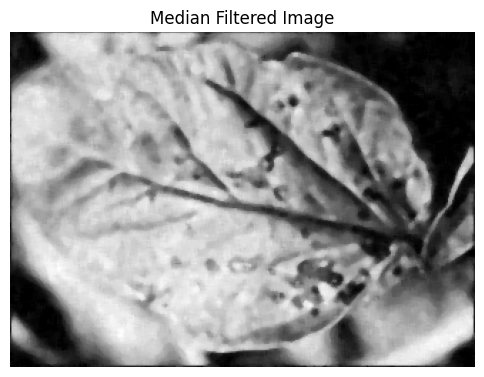

In [ ]:
median_filtered = cv2.medianBlur(noisy, 5)

plt.figure(figsize=(6,6))
plt.imshow(median_filtered, cmap="gray")
plt.title("Median Filtered Image")
plt.axis("off")
plt.show()

This cell provides a comparative visualization of the noisy image alongside the results of both the mean filter and the median filter. This allows for a direct visual assessment of how each filtering technique performs in reducing noise.

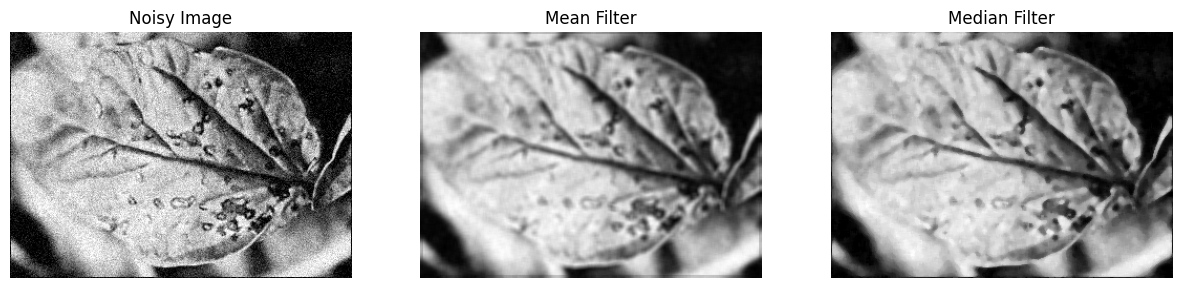

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(noisy, cmap="gray")
plt.title("Noisy Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mean_filtered, cmap="gray")
plt.title("Mean Filter")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(median_filtered, cmap="gray")
plt.title("Median Filter")
plt.axis("off")

plt.show()

This cell calculates and displays objective image quality metrics to quantitatively assess the performance of the mean and median filters. It computes Mean Squared Error (MSE), Peak Signal-to-Noise Ratio (PSNR), and Structural Similarity Index (SSIM) by comparing the filtered images to the original grayscale image.

In [ ]:
mse_mean = mean_squared_error(gray, mean_filtered)
psnr_mean = peak_signal_noise_ratio(gray, mean_filtered)
ssim_mean = structural_similarity(gray, mean_filtered)

mse_median = mean_squared_error(gray, median_filtered)
psnr_median = peak_signal_noise_ratio(gray, median_filtered)
ssim_median = structural_similarity(gray, median_filtered)

print("Mean Filter")
print("MSE:", mse_mean)
print("PSNR:", psnr_mean)
print("SSIM:", ssim_mean)

print("\nMedian Filter")
print("MSE:", mse_median)
print("PSNR:", psnr_median)
print("SSIM:", ssim_median)

Mean Filter
MSE: 398.4443545229082
PSNR: 22.127126830933083
SSIM: 0.7647240755749769

Median Filter
MSE: 213.06239394334943
PSNR: 24.84573558474842
SSIM: 0.795093827406851


This performs histogram equalization on the median-filtered image. Histogram equalization is a technique used to improve the contrast of an image by stretching the intensity range, making features more discernible, especially in images with poor contrast.

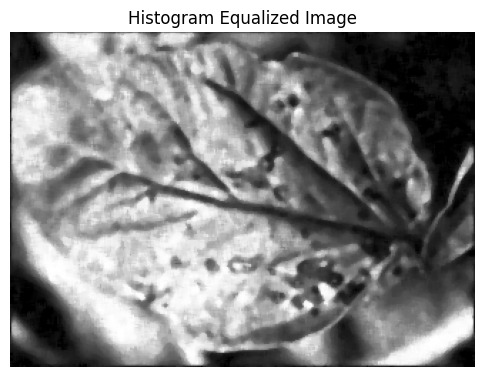

In [ ]:
enhanced = cv2.equalizeHist(median_filtered)

plt.figure(figsize=(6,6))
plt.imshow(enhanced, cmap="gray")
plt.title("Histogram Equalized Image")
plt.axis("off")
plt.show()

It displays the histogram of the image after histogram equalization. The histogram visually represents the distribution of pixel intensities, allowing us to see how the equalization process has spread out the pixel values to enhance contrast.

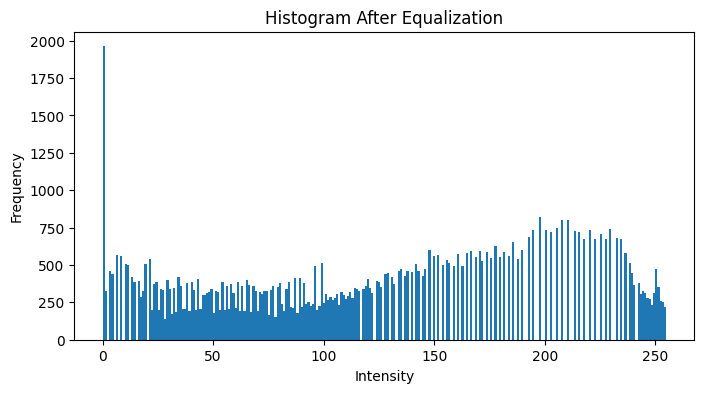

In [ ]:
plt.figure(figsize=(8,4))

plt.hist(enhanced.ravel(), bins=256)

plt.title("Histogram After Equalization")
plt.xlabel("Intensity")
plt.ylabel("Frequency")

plt.show()

This cell applies global thresholding to the histogram-equalized image. Global thresholding uses a single fixed threshold value (here, 120) across the entire image to separate foreground (disease regions) from background, creating a binary image.

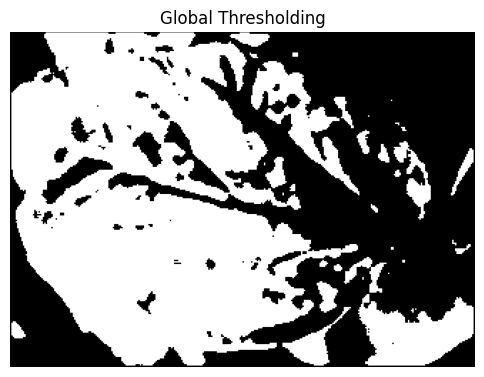

In [ ]:
threshold_value = 120

_, global_threshold = cv2.threshold(
    enhanced,
    threshold_value,
    255,
    cv2.THRESH_BINARY
)

plt.figure(figsize=(6,6))
plt.imshow(global_threshold, cmap="gray")
plt.title("Global Thresholding")
plt.axis("off")
plt.show()

Here Otsu's thresholding is applied , an automatic global thresholding method, to the histogram-equalized image. Otsu's method finds an optimal threshold value by maximizing the variance between the foreground and background pixel classes, which is particularly useful for images with bimodal histograms.

Otsu Threshold Value: 125.0


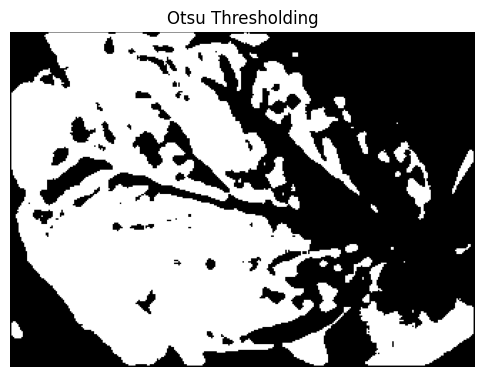

In [ ]:
otsu_value, otsu_threshold = cv2.threshold(
    enhanced,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

print("Otsu Threshold Value:", otsu_value)

plt.figure(figsize=(6,6))
plt.imshow(otsu_threshold, cmap="gray")
plt.title("Otsu Thresholding")
plt.axis("off")
plt.show()

This performs adaptive thresholding, a technique that calculates different threshold values for different small regions of the image. This method is effective for images with varying illumination across different areas, providing a more robust segmentation compared to global thresholding.

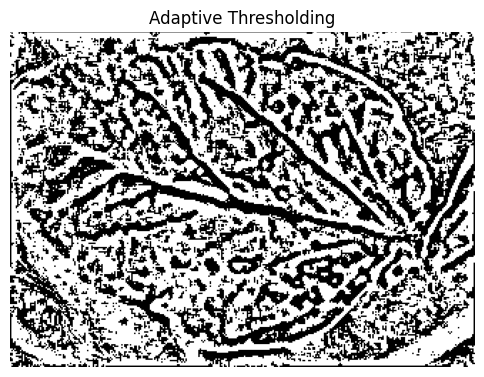

In [ ]:
adaptive_threshold = cv2.adaptiveThreshold(
    enhanced,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11,
    2
)

plt.figure(figsize=(6,6))
plt.imshow(adaptive_threshold, cmap="gray")
plt.title("Adaptive Thresholding")
plt.axis("off")
plt.show()

This provides a comparative visualization of the results from global, Otsu's, and adaptive thresholding methods. This comparison helps to understand which thresholding technique best separates the diseased regions from the healthy parts of the leaf.

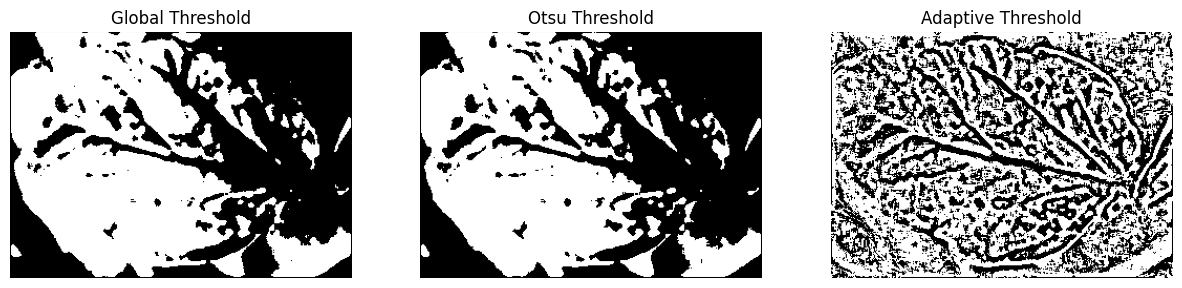

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(global_threshold, cmap="gray")
plt.title("Global Threshold")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(otsu_threshold, cmap="gray")
plt.title("Otsu Threshold")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(adaptive_threshold, cmap="gray")
plt.title("Adaptive Threshold")
plt.axis("off")

plt.show()

This cell applies the Sobel operator for edge detection on the enhanced (histogram-equalized) image. The Sobel filter computes the gradient approximation of image intensity functions, highlighting areas of high intensity change (edges) in both horizontal and vertical directions.

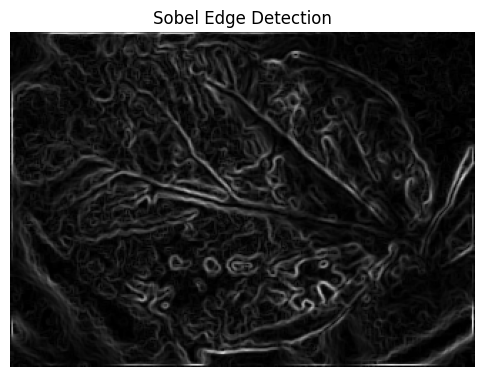

In [ ]:
sobel_x = cv2.Sobel(
    enhanced,
    cv2.CV_64F,
    1, 0,
    ksize=3
)

sobel_y = cv2.Sobel(
    enhanced,
    cv2.CV_64F,
    0, 1,
    ksize=3
)

sobel = cv2.magnitude(sobel_x, sobel_y)

sobel = cv2.normalize(
    sobel,
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype(np.uint8)

plt.figure(figsize=(6,6))
plt.imshow(sobel, cmap="gray")
plt.title("Sobel Edge Detection")
plt.axis("off")
plt.show()

This applies the Canny edge detection algorithm to the enhanced image. Canny is a multi-stage algorithm widely regarded as an optimal edge detector due to its ability to detect a wide range of edges while minimizing false positives and providing thin, continuous edges.

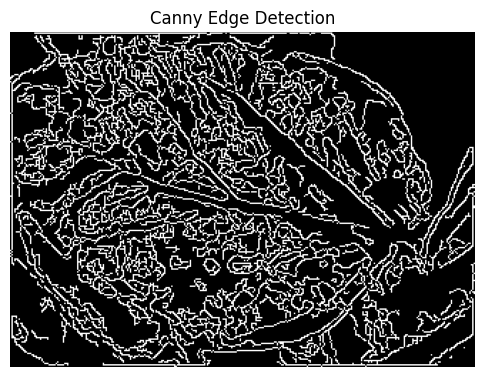

In [ ]:
canny = cv2.Canny(
    enhanced,
    50,
    150
)

plt.figure(figsize=(6,6))
plt.imshow(canny, cmap="gray")
plt.title("Canny Edge Detection")
plt.axis("off")
plt.show()

This visually compares the results of Sobel and Canny edge detection algorithms. This allows for an assessment of which method provides more accurate and visually clear edges for the plant leaf images.

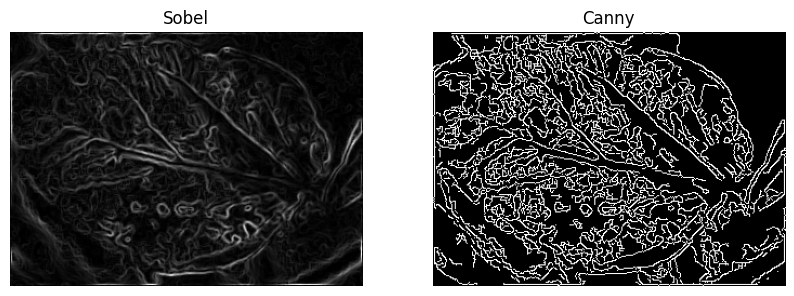

In [ ]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(sobel, cmap="gray")
plt.title("Sobel")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(canny, cmap="gray")
plt.title("Canny")
plt.axis("off")

plt.show()

This applies morphological operations (opening followed by closing) to refine the binary image obtained from Otsu's thresholding. Opening removes small objects and smooths boundaries, while closing fills small holes and closes gaps, helping to clean up the segmented regions and produce a more coherent mask.

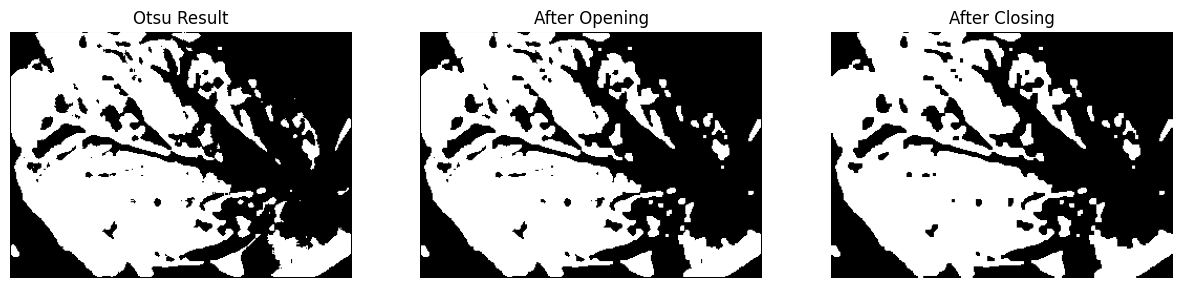

In [ ]:
kernel = np.ones((3,3), np.uint8)

opened = cv2.morphologyEx(
    otsu_threshold,
    cv2.MORPH_OPEN,
    kernel
)

cleaned = cv2.morphologyEx(
    opened,
    cv2.MORPH_CLOSE,
    kernel
)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(otsu_threshold, cmap="gray")
plt.title("Otsu Result")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(opened, cmap="gray")
plt.title("After Opening")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(cleaned, cmap="gray")
plt.title("After Closing")
plt.axis("off")

plt.show()

This performs Watershed segmentation, a powerful algorithm for separating touching objects in an image. It uses distance transform, foreground markers, and background markers to delineate individual diseased regions, creating a more precise segmentation than simple thresholding.

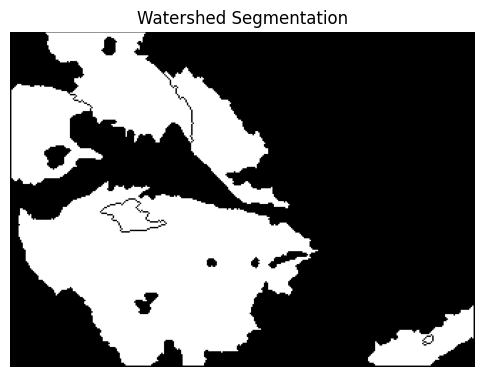

In [ ]:
dist = cv2.distanceTransform(
    cleaned,
    cv2.DIST_L2,
    5
)

_, foreground = cv2.threshold(
    dist,
    0.4 * dist.max(),
    255,
    0
)

foreground = np.uint8(foreground)

background = cv2.dilate(
    cleaned,
    kernel,
    iterations=2
)

unknown = cv2.subtract(
    background,
    foreground
)

num_labels, markers = cv2.connectedComponents(
    foreground
)

markers = markers + 1

markers[unknown == 255] = 0

watershed_input = cv2.cvtColor(
    image,
    cv2.COLOR_RGB2BGR
)

markers = cv2.watershed(
    watershed_input,
    markers
)

watershed_result = np.zeros_like(gray)

watershed_result[markers > 1] = 255

plt.figure(figsize=(6,6))
plt.imshow(watershed_result, cmap="gray")
plt.title("Watershed Segmentation")
plt.axis("off")
plt.show()

This visualizes the intermediate steps involved in the Watershed segmentation process. It shows the `cleaned` binary image (after morphological operations), the `foreground` markers identified from the distance transform, and the `background` region. These components are crucial for the Watershed algorithm to correctly segment objects.

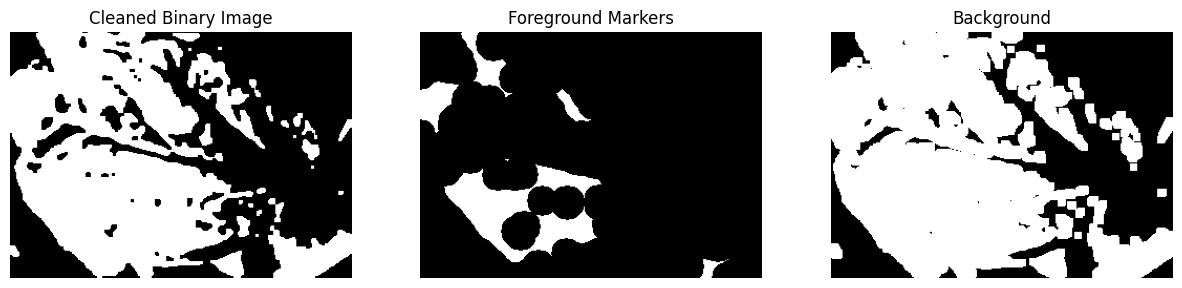

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(cleaned, cmap="gray")
plt.title("Cleaned Binary Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(foreground, cmap="gray")
plt.title("Foreground Markers")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(background, cmap="gray")
plt.title("Background")
plt.axis("off")

plt.show()


This cell converts the loaded grayscale mask into a binary ground truth mask, where pixel values are either 0 or 255. This binary representation is essential for quantitative comparison with the segmented output from the image processing pipeline.

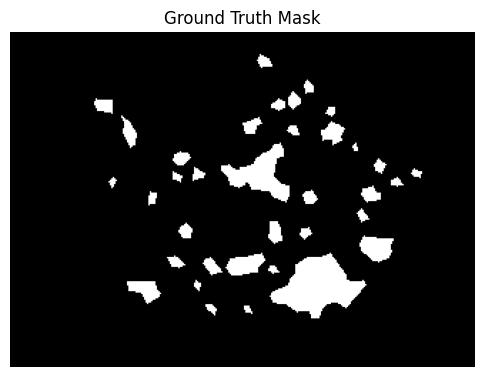

In [ ]:
ground_truth = np.where(
    mask > 0,
    255,
    0
).astype(np.uint8)

plt.figure(figsize=(6,6))
plt.imshow(ground_truth, cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")
plt.show()

This cell visually compares the binary ground truth mask with the predicted segmentation result obtained after morphological cleaning. This side-by-side display helps to qualitatively assess the accuracy of the segmentation pipeline.

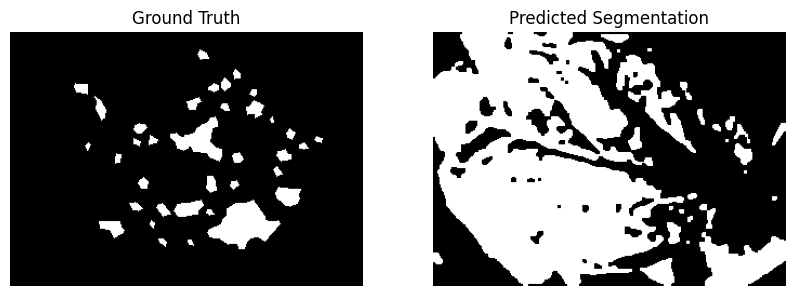

In [ ]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(ground_truth, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cleaned, cmap="gray")
plt.title("Predicted Segmentation")
plt.axis("off")

plt.show()

This cell defines a function, `calculate_metrics`, which computes standard segmentation evaluation metrics: Intersection over Union (IoU), Dice coefficient, and Accuracy. These metrics quantify the overlap and similarity between the predicted segmentation and the ground truth mask.

In [ ]:
def calculate_metrics(prediction, ground_truth):

    pred = prediction > 0
    gt = ground_truth > 0

    intersection = np.logical_and(
        pred,
        gt
    ).sum()

    union = np.logical_or(
        pred,
        gt
    ).sum()

    iou = intersection / union if union != 0 else 0

    dice = (
        2 * intersection /
        (pred.sum() + gt.sum())
        if (pred.sum() + gt.sum()) != 0
        else 0
    )

    accuracy = np.mean(pred == gt)

    return iou, dice, accuracy

This cell calls the `calculate_metrics` function with the morphologically `cleaned` segmentation result and the `ground_truth` mask. It then prints the calculated IoU, Dice coefficient, and Accuracy, providing a quantitative evaluation of the segmentation performance.

In [ ]:
iou, dice, accuracy = calculate_metrics(
    cleaned,
    ground_truth
)

print("Segmentation Results")
print("--------------------")
print("IoU      :", iou)
print("Dice     :", dice)
print("Accuracy :", accuracy)

Segmentation Results
--------------------
IoU      : 0.044900021655959
Dice     : 0.0859412780656304
Accuracy : 0.48188226080146196


This cell presents a comprehensive visualization of the entire image processing pipeline. It displays the original image, the noisy image, the median-filtered image, the Otsu thresholded image, the morphologically cleaned result, and the ground truth mask. This summary allows for a complete overview of the steps taken and their impact on the image.

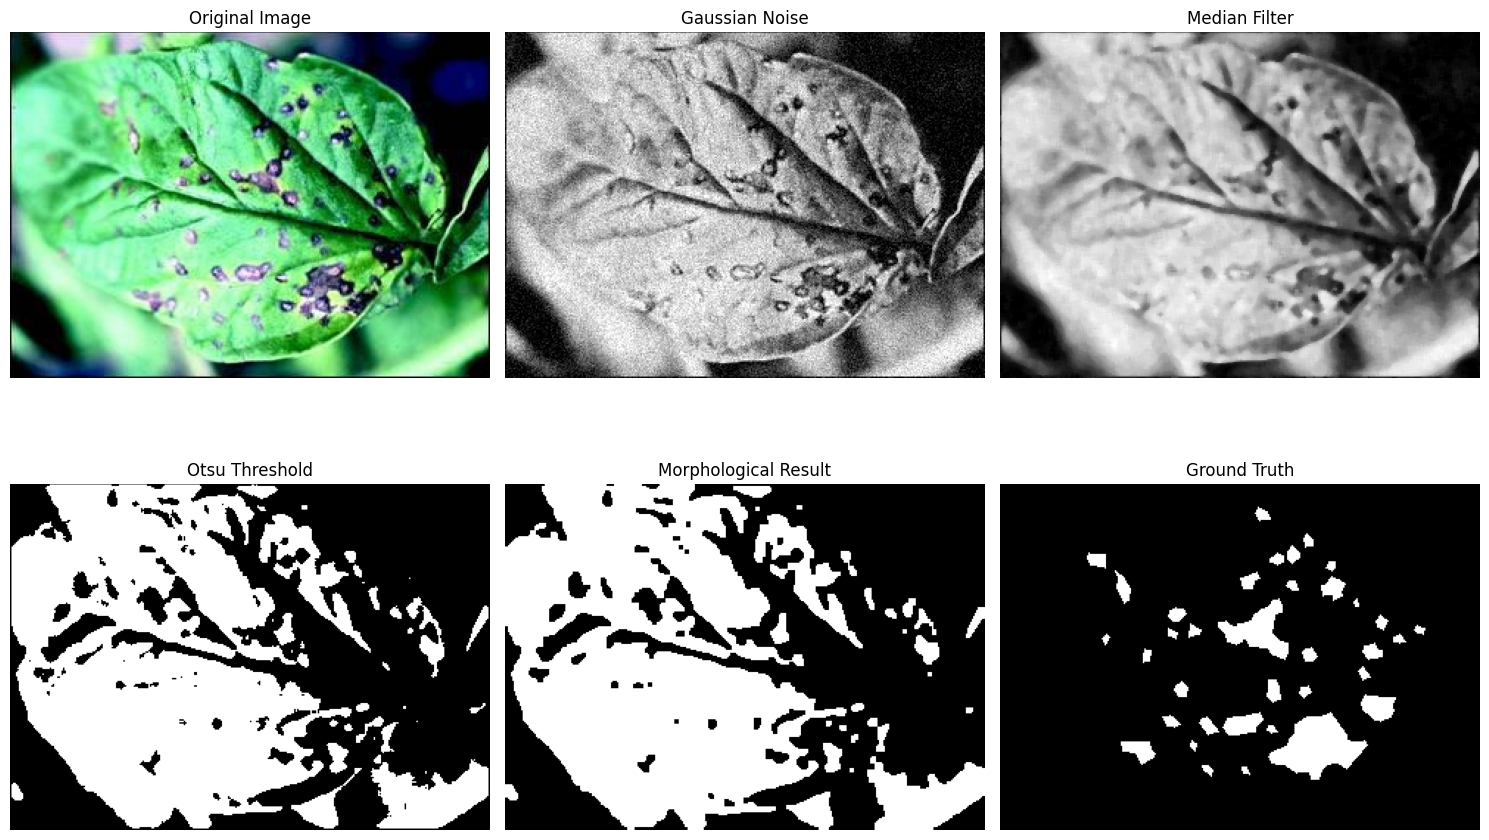

In [ ]:
plt.figure(figsize=(15,10))

plt.subplot(2,3,1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(noisy, cmap="gray")
plt.title("Gaussian Noise")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(median_filtered, cmap="gray")
plt.title("Median Filter")
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(otsu_threshold, cmap="gray")
plt.title("Otsu Threshold")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(cleaned, cmap="gray")
plt.title("Morphological Result")
plt.axis("off")

plt.subplot(2,3,6)
plt.imshow(ground_truth, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.tight_layout()
plt.show()